# 28. Cross-Sectional Alpha Model

## Objective
Build a **rank-based cross-sectional alpha model** using regression (not classification), evaluate rank IC, and backtest a simple top/bottom portfolio.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List
import logging

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from xgboost import XGBRegressor

try:
    from lightgbm import LGBMRegressor
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 320)
pd.set_option('display.width', 240)

TRAIN_START = pd.Timestamp('2023-01-01')
TRAIN_END = pd.Timestamp('2024-12-31')
TEST_START = pd.Timestamp('2025-01-01')
TEST_END = pd.Timestamp('2025-12-31')

TOP_N = 10
ANNUALIZATION_DAYS = 252
RANDOM_STATE = 42

logger = logging.getLogger('cross_sectional_alpha')
if not logger.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(h)
logger.setLevel(logging.INFO)

if not HAS_LIGHTGBM:
    logger.info('LightGBM is not installed. Notebook will use XGBoost results for model selection.')


In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Unable to locate project root.')


def sharpe_ratio(daily_returns: pd.Series, annualization: int = ANNUALIZATION_DAYS) -> float:
    mu = float(daily_returns.mean())
    sigma = float(daily_returns.std(ddof=1))
    if sigma == 0.0 or np.isnan(sigma):
        return np.nan
    return (mu / sigma) * np.sqrt(annualization)


def max_drawdown(equity: pd.Series) -> float:
    running_max = equity.cummax()
    dd = equity / running_max - 1.0
    return float(dd.min()) if len(dd) else np.nan


def strategy_stats(daily_returns: pd.Series) -> Dict[str, float]:
    s = daily_returns.sort_index()
    if len(s) == 0:
        return {'Total return': np.nan, 'Sharpe ratio': np.nan, 'Max drawdown': np.nan}
    eq = (1.0 + s).cumprod()
    return {
        'Total return': float(eq.iloc[-1] - 1.0),
        'Sharpe ratio': sharpe_ratio(s),
        'Max drawdown': max_drawdown(eq),
    }


ROOT = resolve_project_root()
BASE = ROOT / 'ml_pipeline'
DATA_PATH = BASE / 'Market_Data' / 'processed' / 'final_model_dataset_with_volatility.parquet'
STEP26_PATH = BASE / 'Market_Data' / 'final' / 'improved_signal_dataset.parquet'
STEP27_PATH = BASE / 'Market_Data' / 'final' / 'alternative_signal_dataset.parquet'
OUT_PATH = BASE / 'Market_Data' / 'final' / 'cross_sectional_alpha_results.parquet'

assert DATA_PATH.exists(), f'Missing dataset: {DATA_PATH}'

df = pd.read_parquet(DATA_PATH).copy()
df['Date'] = pd.to_datetime(df['Date'])
df['Ticker'] = df['Ticker'].astype(str)
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)
g_close = df.groupby('Ticker', sort=False)['Close']
g_ret = df.groupby('Ticker', sort=False)['Return']

# STEP 1: TARGET REDEFINITION (regression only)
df['target_future_return_t3'] = g_close.shift(-3) / df['Close'] - 1.0

# STEP 2: CROSS-SECTIONAL NORMALIZATION (daily rank + z-score)
df['target_rank_cs'] = df.groupby('Date')['target_future_return_t3'].rank(pct=True)
daily_target_mean = df.groupby('Date')['target_future_return_t3'].transform('mean')
daily_target_std = df.groupby('Date')['target_future_return_t3'].transform('std').replace(0, np.nan)
df['target_zscore_cs'] = ((df['target_future_return_t3'] - daily_target_mean) / daily_target_std).fillna(0.0)

feature_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume', 'Return',
    'RSI', 'ROC', 'EMA_20', 'SMA_20', 'MACD', 'MACD_Signal',
    'ATR', 'Volatility_20', 'Volatility_50', 'Volume_MA_20',
    'SP500_RET', 'DOW_RET', 'GOLD_RET', 'OIL_RET', 'USDINR_RET', 'VIX_RET', 'NIFTY_RET',
    'Event_Count', 'Avg_Tone', 'War_Flag', 'Crisis_Flag', 'Inflation_Flag', 'Rate_Hike_Flag',
    'return_roll_mean_5', 'return_roll_std_5', 'momentum_5',
    'return_roll_mean_10', 'return_roll_std_10', 'momentum_10',
    'return_roll_mean_20', 'return_roll_std_20', 'momentum_20',
]
feature_cols = [c for c in feature_cols if c in df.columns]

work = df[['Ticker', 'Date', 'target_future_return_t3', 'target_rank_cs', 'target_zscore_cs'] + feature_cols].copy()
work = work.replace([np.inf, -np.inf], np.nan)
work = work.dropna(subset=['target_future_return_t3'] + feature_cols).copy()

train_mask = (work['Date'] >= TRAIN_START) & (work['Date'] <= TRAIN_END)
test_mask = (work['Date'] >= TEST_START) & (work['Date'] <= TEST_END)
assert train_mask.any() and test_mask.any(), 'Train/Test split is empty.'

X_train = work.loc[train_mask, feature_cols]
X_test = work.loc[test_mask, feature_cols]
y_train = work.loc[train_mask, 'target_future_return_t3'].to_numpy(dtype=float)

# STEP 3: MODEL TRAINING (regression)
models_pred: Dict[str, np.ndarray] = {}

xgb_reg = XGBRegressor(
    n_estimators=700,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=2.0,
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_reg.fit(X_train, y_train)
models_pred['XGBoostRegressor'] = xgb_reg.predict(X_test)

if HAS_LIGHTGBM:
    lgb_reg = LGBMRegressor(
        objective='regression',
        n_estimators=700,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_STATE,
    )
    lgb_reg.fit(X_train, y_train)
    models_pred['LightGBMRegressor'] = lgb_reg.predict(X_test)

test_df = work.loc[test_mask, ['Ticker', 'Date', 'target_future_return_t3', 'target_rank_cs', 'target_zscore_cs']].copy()
for k, v in models_pred.items():
    test_df[f'pred_{k}'] = v

logger.info('Training complete. Test rows: %s', f'{len(test_df):,}')
display(test_df.head(10))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008938 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8595
[LightGBM] [Info] Number of data points in the train set: 39733, number of used features: 38
[LightGBM] [Info] Start training from score 0.004491


[INFO] Training complete. Test rows: 23,520


,Ticker,Date,target_future_return_t3,target_rank_cs,target_zscore_cs,pred_XGBoostRegressor,pred_LightGBMRegressor
421,ABB,2025-01-01,-0.044476,0.114583,-1.056459,0.019528,0.003123
422,ABB,2025-01-02,-0.026916,0.479167,-0.249188,0.009419,0.015437
423,ABB,2025-01-03,-0.021051,0.583333,0.162705,0.012527,0.028985
424,ABB,2025-01-06,-0.020822,0.343750,-0.446947,0.011315,0.035563
425,ABB,2025-01-07,-0.043326,0.322917,-0.422147,0.016864,0.020042
426,ABB,2025-01-08,-0.082282,0.270833,-0.729417,0.010574,0.020480
427,ABB,2025-01-09,-0.051809,0.187500,-0.766272,0.013038,0.023781
428,ABB,2025-01-10,-0.034587,0.166667,-0.738153,0.002628,0.012791
429,ABB,2025-01-13,0.032574,0.541667,-0.052060,-0.008812,0.009896
430,ABB,2025-01-14,0.061969,0.937500,1.430968,0.010845,0.040337


,Model,Mean_IC,IC_Std,IC_Hit_Rate,IC_Target_0.02,IC_Target_0.05
0,LightGBMRegressor,0.0183,0.1396,0.5551,False,False
1,XGBoostRegressor,0.0039,0.1692,0.5510,False,False


,Strategy,Total return,Sharpe ratio,Max drawdown
0,Cross-sectional (LightGBMRegressor),0.7869,2.628,-0.13


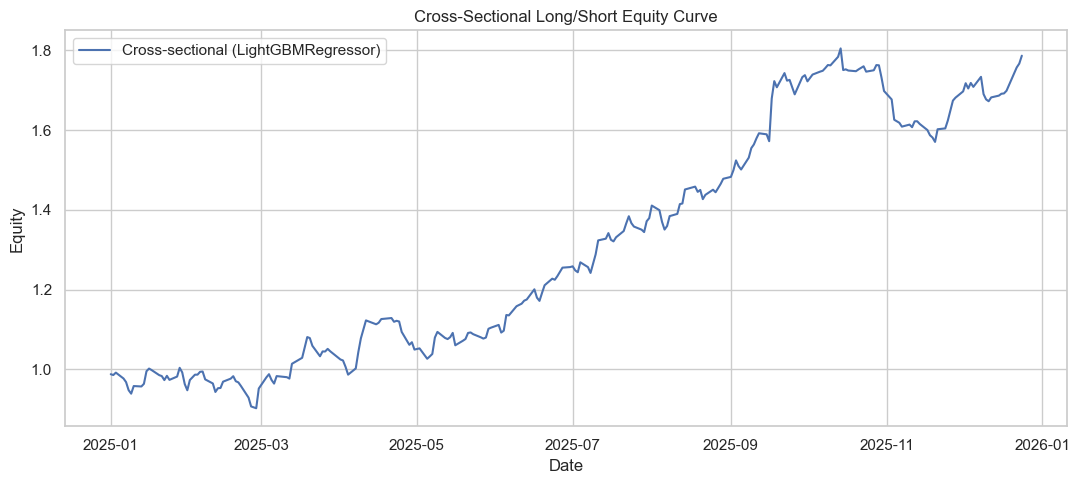

In [3]:
# STEP 4: RANK EVALUATION (Spearman IC)
ic_rows: List[Dict[str, float]] = []
for model_name in models_pred.keys():
    pred_col = f'pred_{model_name}'

    daily_ic = []
    for dt, g in test_df.groupby('Date', sort=True):
        if len(g) < 20:
            continue
        corr, _ = spearmanr(g[pred_col], g['target_future_return_t3'])
        if np.isnan(corr):
            continue
        daily_ic.append((dt, float(corr)))

    if len(daily_ic) == 0:
        ic_mean = np.nan
        ic_std = np.nan
        ic_hit = np.nan
    else:
        ic_series = pd.Series([x[1] for x in daily_ic])
        ic_mean = float(ic_series.mean())
        ic_std = float(ic_series.std(ddof=1))
        ic_hit = float((ic_series > 0).mean())

    ic_rows.append({
        'Model': model_name,
        'Mean_IC': ic_mean,
        'IC_Std': ic_std,
        'IC_Hit_Rate': ic_hit,
        'IC_Target_0.02': bool(pd.notna(ic_mean) and ic_mean >= 0.02),
        'IC_Target_0.05': bool(pd.notna(ic_mean) and ic_mean >= 0.05),
    })

ic_df = pd.DataFrame(ic_rows).sort_values('Mean_IC', ascending=False).reset_index(drop=True)
display(ic_df.round(4))

best_model = str(ic_df.iloc[0]['Model'])
pred_col_best = f'pred_{best_model}'

# STEP 5: PORTFOLIO CONSTRUCTION (long top 10, short bottom 10, equal weight)
ls_rows = []
for dt, g in test_df.groupby('Date', sort=True):
    if len(g) < (TOP_N * 2):
        continue
    g = g.copy()
    g = g.sort_values(pred_col_best, ascending=False)

    long_leg = g.head(TOP_N).copy()
    short_leg = g.tail(TOP_N).copy()

    long_leg['side'] = 1
    short_leg['side'] = -1

    picks = pd.concat([long_leg, short_leg], ignore_index=True)
    picks['weight'] = picks['side'] * (1.0 / TOP_N)
    picks['portfolio_return_component'] = picks['weight'] * picks['target_future_return_t3']
    ls_rows.append(picks)

assert len(ls_rows) > 0, 'No long/short portfolios were formed.'
portfolio_df = pd.concat(ls_rows, ignore_index=True)
daily_ls = portfolio_df.groupby('Date', as_index=True)['portfolio_return_component'].sum().sort_index()

# STEP 6: BACKTEST
stats_ls = strategy_stats(daily_ls)
backtest_df = pd.DataFrame([{'Strategy': f'Cross-sectional ({best_model})', **stats_ls}])
display(backtest_df.round(4))

plt.figure(figsize=(11, 5))
plt.plot((1.0 + daily_ls).cumprod(), label=f'Cross-sectional ({best_model})')
plt.title('Cross-Sectional Long/Short Equity Curve')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.tight_layout()
plt.show()


,Strategy,Total return,Sharpe ratio,Max drawdown
0,Cross-sectional (LightGBMRegressor),0.7869,2.6280,-0.1300
1,"Buy & Hold (equal-weight universe, t+3)",0.3292,1.2280,-0.2898
2,Step-27 simple strategy,0.2479,1.1594,-0.1477
3,Step-26 simple strategy,0.1451,0.7501,-0.1751


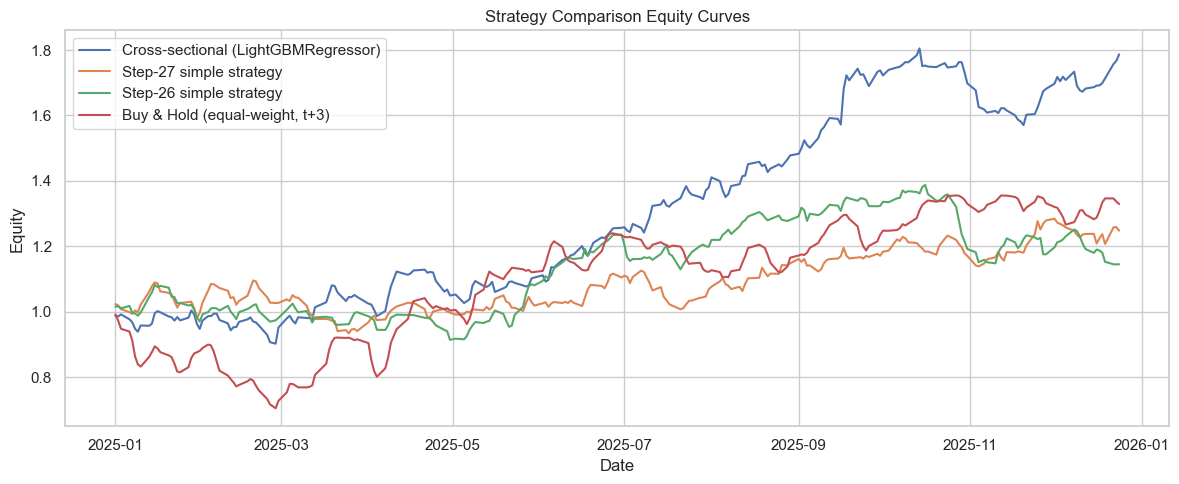

Best model: LightGBMRegressor
IC mean: 0.0183
IC stability (std): 0.1396
Sharpe: 2.6280
Saved results: c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\cross_sectional_alpha_results.parquet
Notebook 28 completed: cross-sectional alpha model built and evaluated.


In [4]:
# STEP 7: COMPARE vs Step-27, Step-26, Buy & Hold
cmp_rows = [{'Strategy': f'Cross-sectional ({best_model})', **stats_ls}]

if STEP27_PATH.exists():
    s27 = pd.read_parquet(STEP27_PATH).copy()
    s27['Date'] = pd.to_datetime(s27['Date'])
    s27_daily = (
        s27[(s27['Date'] >= TEST_START) & (s27['Date'] <= TEST_END)]
        .groupby('Date', as_index=True)['simple_strategy_return']
        .sum(min_count=1)
        .fillna(0.0)
        .sort_index()
    )
    cmp_rows.append({'Strategy': 'Step-27 simple strategy', **strategy_stats(s27_daily)})

if STEP26_PATH.exists():
    s26 = pd.read_parquet(STEP26_PATH).copy()
    s26['Date'] = pd.to_datetime(s26['Date'])
    s26_daily = (
        s26[(s26['Date'] >= TEST_START) & (s26['Date'] <= TEST_END)]
        .groupby('Date', as_index=True)['simple_strategy_return']
        .sum(min_count=1)
        .fillna(0.0)
        .sort_index()
    )
    cmp_rows.append({'Strategy': 'Step-26 simple strategy', **strategy_stats(s26_daily)})

# Buy & Hold benchmark on same test period using equal-weight universe t+3 forward return.
bh_daily = (
    test_df.groupby('Date', as_index=True)['target_future_return_t3']
    .mean()
    .sort_index()
)
cmp_rows.append({'Strategy': 'Buy & Hold (equal-weight universe, t+3)', **strategy_stats(bh_daily)})

compare_df = pd.DataFrame(cmp_rows).sort_values('Sharpe ratio', ascending=False).reset_index(drop=True)
display(compare_df.round(4))

plt.figure(figsize=(12, 5))
plt.plot((1.0 + daily_ls).cumprod(), label=f'Cross-sectional ({best_model})')
if 's27_daily' in locals() and len(s27_daily) > 0:
    plt.plot((1.0 + s27_daily).cumprod(), label='Step-27 simple strategy')
if 's26_daily' in locals() and len(s26_daily) > 0:
    plt.plot((1.0 + s26_daily).cumprod(), label='Step-26 simple strategy')
plt.plot((1.0 + bh_daily).cumprod(), label='Buy & Hold (equal-weight, t+3)')
plt.title('Strategy Comparison Equity Curves')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.tight_layout()
plt.show()

# STEP 8: OUTPUT
ic_mean_best = float(ic_df.loc[ic_df['Model'] == best_model, 'Mean_IC'].iloc[0])
ic_stability_best = float(ic_df.loc[ic_df['Model'] == best_model, 'IC_Std'].iloc[0])
sharpe_best = float(stats_ls['Sharpe ratio'])

print(f'Best model: {best_model}')
print(f'IC mean: {ic_mean_best:.4f}')
print(f'IC stability (std): {ic_stability_best:.4f}')
print(f'Sharpe: {sharpe_best:.4f}')

daily_map = daily_ls.to_dict()
save_df = portfolio_df.copy()
save_df['daily_portfolio_return'] = save_df['Date'].map(daily_map)
save_df['model_selected'] = best_model
save_df['ic_mean_selected'] = ic_mean_best
save_df['ic_std_selected'] = ic_stability_best
save_df['sharpe_selected'] = sharpe_best

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
save_df.to_parquet(OUT_PATH, index=False)

print(f'Saved results: {OUT_PATH}')
print('Notebook 28 completed: cross-sectional alpha model built and evaluated.')
